# **Data Exploration**
### **Objective**
To understand transaction data, identify patterns, and validate whether the dataset supports subscription detection and prediction tasks.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("C:\\Users\\admin\\OneDrive\\Desktop\\JOB\\OPUS\\Training_Assessment\\GroupTask1_Mansi_Samyak\\AI_Subscription_and_Auto_Debit_Intelligence_System\\Group_Project_AI_Subscription_and_Auto_Debit_Intelligence_System\\data\\subscription_dataset.csv")
df.head()

,CustomerID,TransactionID,Date,Description,Merchant,Amount,Balance,SubscriptionFlag
0,C1,T1,2025-01-01,Salary Credit,Company,43677,55183,0
1,C1,T2,2025-01-02,Payment to Cafe Coffee Day,Cafe Coffee Day,-1691,53492,0
2,C1,T3,2025-01-02,Payment to Medical Store,Medical Store,-781,52711,0
3,C1,T4,2025-01-03,Payment to Uber,Uber,-1131,51580,0
4,C1,T5,2025-01-04,Gym Membership Subscription,Gym Membership,-1200,50380,1


In [10]:
df.shape

(98717, 8)

In [11]:
df.columns

Index(['CustomerID', 'TransactionID', 'Date', 'Description', 'Merchant',
       'Amount', 'Balance', 'SubscriptionFlag'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98717 entries, 0 to 98716
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        98717 non-null  object
 1   TransactionID     98717 non-null  object
 2   Date              98717 non-null  object
 3   Description       98717 non-null  object
 4   Merchant          98717 non-null  object
 5   Amount            98717 non-null  int64 
 6   Balance           98717 non-null  int64 
 7   SubscriptionFlag  98717 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 6.0+ MB


In [14]:
df.describe()

,Amount,Balance,SubscriptionFlag
count,98717.000000,98717.000000,98717.000000
mean,64.673076,51880.182441,0.061631
std,6401.146556,48984.222080,0.240485
min,-2000.000000,0.000000,0.000000
25%,-1500.000000,12554.000000,0.000000
50%,-999.000000,41105.000000,0.000000
75%,-505.000000,76928.000000,0.000000
max,49964.000000,408323.000000,1.000000


In [15]:
df.isnull().sum()

CustomerID          0
TransactionID       0
Date                0
Description         0
Merchant            0
Amount              0
Balance             0
SubscriptionFlag    0
dtype: int64

No significant missing values.

In [20]:
# Unique Customers & Merchants
print("Unique Customers & Merchants")
print("Total Customers:", df["CustomerID"].nunique())
print("Total Merchants:", df["Merchant"].nunique())

Unique Customers & Merchants
Total Customers: 500
Total Merchants: 15


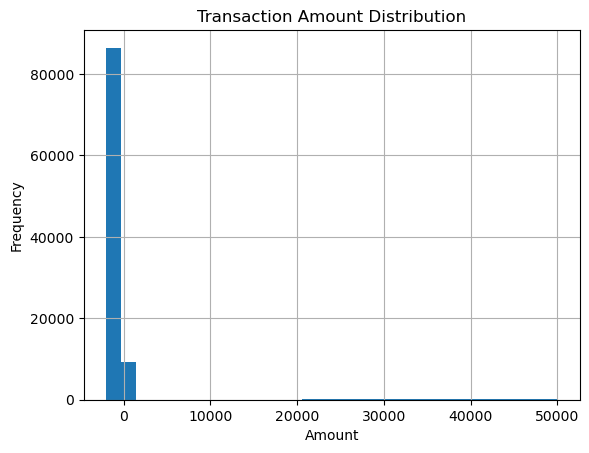

In [35]:
# Transaction Amount Distribution
plt.figure()
df["Amount"].hist(bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

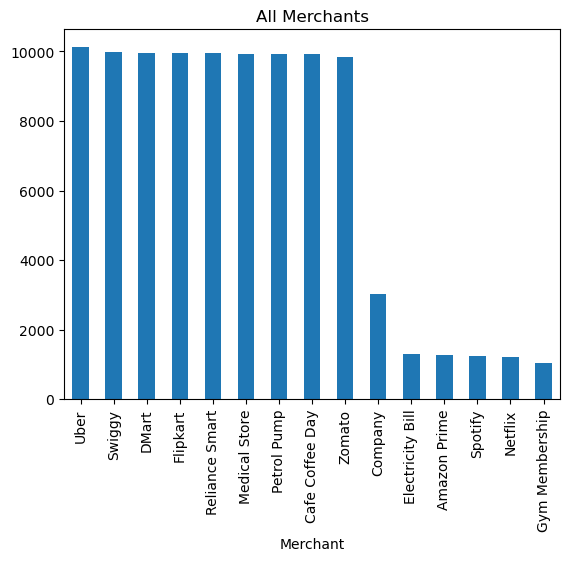

In [ ]:
# All Merchants
df["Merchant"].value_counts().plot(kind="bar")
plt.title("All Merchants")
plt.xlabel("Merchant")
plt.ylabel("Frequency")
plt.show()

Frequently occurring merchants indicate potential subscription services.

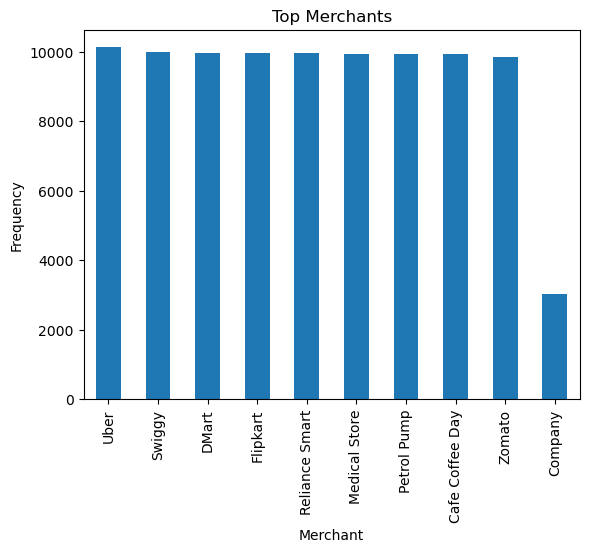

In [33]:
# Top Merchants(10)
df["Merchant"].value_counts().head(10).plot(kind="bar")
plt.title("Top Merchants")
plt.xlabel("Merchant")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Recurring Pattern Check
# reset_index(name="Count"): Generate a new DataFrame or Series with the index reset. This is useful when the index needs to be treated as a column
recurring = df.groupby(["CustomerID", "Merchant"]).size().reset_index(name="Count")

recurring.sort_values(by="Count", ascending=False).head(10)

,CustomerID,Merchant,Count
3313,C347,Zomato,36
2741,C303,Medical Store,36
5541,C64,Flipkart,35
1784,C232,Flipkart,34
3172,C336,Zomato,34
141,C109,Reliance Smart,34
793,C158,Flipkart,34
164,C110,Reliance Smart,34
5319,C498,Zomato,34
3946,C395,Swiggy,34


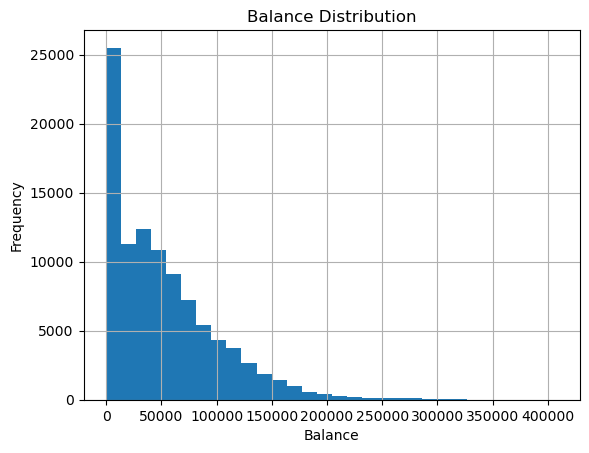

In [ ]:
# Balance Analysis
plt.figure()
df["Balance"].hist(bins=30)
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

### **Key Observations**

- The dataset contains multiple customers and merchants.
- Certain transactions repeat frequently, indicating subscription patterns.
- Transaction amounts are consistent for specific merchants.
- Balance varies across time, enabling risk analysis.
- The dataset is suitable for NLP-based subscription detection and ML-based prediction.